<span style="font-size:14px">

## <span style="color: Gold"> **LangGraph**

1. 상태 기반(그래프 기반) 질의 처리
    - 질문을 노드단위로 처리하고 노드간 흐름을 그래프(edge)로 연결
    - 질문 --> 관련 문서 검색 --> 필요하면 문서 평가 --> 조건부 분기 --> 생성 --> 최종답변

2. RAG(Retrieval-Augmented Generation)와 관계
    - LangGraph는 LLM + VectorDB 기반 RAG 방식을 자연스럽게 연결
    - 내부 문서와 웹 검색(외부 문서)을 모두 활용하여 조건부 분기 가능
<br><br>
- **질문이 들어오면 상태(State)가 노드를 타고 이동하며 문서를 검색, 평가, 생성하는 흐름을 구현하는 구조입니다.**
<br><br>
- node : 해야할 일
- edge (조건에 따라 분기시킬 수 있음) : 다음에 어떤일을 할지 연결 (node를 연결)
- conditioanl Edge : 상황에 따라 다음 작업이 달라짐
- graph : node, edge를 관리
<br><br>
- 핵심
    - 상태(state)를 가진다
    - 상태를 입력으로 받아 작동하는 노드들을 만든다
    - 노드와 노드를 연결한다
    - 조건에 따라 다른 노드로 연결되는 엣지를 만든다
    - 그래프 전체를 컴파일해서 실행 가능한 프로그램으로 만든다
<br><br>
- state
    - “현재까지 어떤 정보가 축적되어 있는지 저장하는 공유 메모리”
    - 질문과 문서, 검색 타입, 답변 등을 담는 데이터 구조
    - LangGraph에서는 모든 노드가 이 State를 받아서 필요한 걸 쓰고, 새로운 데이터를 추가해서 다음 노드에 넘김. (노드 간 공통 데이터를 공유, 상태를 기반으로 조건부 분기 가능)
    - 왜 필요함?
        - 내부 검색 결과를 다음 단계에서 써야 함
        - 웹 검색 결과도 다음 단계에서 써야 함
        - LLM이 생성한 답변도 마지막에 넣어야 함
    - 즉, 각 단계가 서로 데이터를 주고받는 그릇이 바로 상태.
<br><br>
- Node
    - 질문 처리 단계별 기능 단위
    - 하나의 독립적인 작업(Task) 또는 함수
    - LangGraph에서는 모든 노드가 "입력 = 상태, 출력 = 상태 업데이트" 형태를 가짐.
    - 노드는 "순서도에서 하나의 박스"라고 보면 됨
        - Retriever Node → 문서를 검색(VectorDB)
        - Grade Node → 문서 평가 및 필터링
        - Web Search Node → 내부 문서가 없을 때 외부 검색 시뮬레이션
        - Generate Node → LLM으로 최종 답변 생성


<br><br>
- Conditional Edge
    - 그래프에서 노드 이동 경로를 동적으로 결정하는 장치 
    - 노드의 실행 결과에 따라 다음에 갈 경로를 다르게 선택하는 길
    - 즉, if문을 그래프에 구현하는 것
    - 너의 코드에서는:
        - 내부 검색 결과가 있으면 → 바로 generate 노드
        - 내부 문서가 없으면 → web_search 노드로 이동
    - 즉, LLM 기반의 스마트한 if/else 흐름 제어가 가능해짐.
<br><br>
- Edge
    - 노드와 노드를 연결하는 선
    - 그래프에서 흐름을 보여주는 화살표

- Graph
    - 노드와 엣지를 연결하는 구조
    - add_node → 노드 추가
    - add_edge → 정방향 엣지 연결
    - add_conditional_edges → 조건부 분기 연결
    - compile() → 그래프를 실행 가능한 앱으로 변환 (흐름도를 실행 가능한 프로그램으로 만드는 과정)
    - invoke() → 질문(State)을 입력하고 결과를 얻음 (해당 그래프를 실제로 실행해봐)
 

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

from typing import List, Literal
from typing_extensions import TypedDict
from dotenv import load_dotenv

# LangChain 관련 임포트
from langchain_core.documents import Document
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader, TextLoader
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

# LangGraph 관련 임포트
from langgraph.graph import StateGraph, START, END

# 환경설정
load_dotenv()

if not os.environ.get('OPENAI_API_KEY'):
    raise ValueError('key check!!!!!')


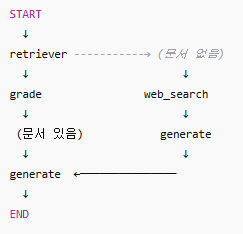

In [ ]:
def langgraph_rag():
    '''VectorDB 기반 LangGraph RAG'''

    # 상태 정의
    class RAGState(TypedDict):
        question : str
        documents : List[Document]
        doc_scores : List[float] # 리트리버가 해주는 유사도 값 저장
        search_type : str
        answer : str


    # 문서 로드
    path = "C:/00AI/LLM/20openai/sample_docs_20251128"
    loader = DirectoryLoader(
        path=path,
        glob='**/*.txt',
        loader_cls=TextLoader,
        loader_kwargs={'encoding':'utf-8'}
        )
    docs = loader.load()



    # vectorDB 구축
    text_spliter = RecursiveCharacterTextSplitter(
        chunk_size=200,
        chunk_overlap=50,
        separators=['\n\n', '\n', '.', ',', ' ']
    )
    splits = text_spliter.split_documents(docs)
    vectorstores = Chroma.from_documents(
        documents=splits,
        embedding=OpenAIEmbeddings(model='text-embedding-3-small'),
        collection_name='langgraph3'
    )
    print(f'vectorDB 구축 완료, chunk개수 : {len(splits)}')

    # llm 초기화
    llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

    # 노드 함수 
    # 리트리버 함수 : LLM에 넘길 컨텍스트를 준비
    def retriever_node(state:RAGState) -> dict :
        '''검색 노드'''
        question = state['question']
        docs_with_scores = vectorstores.similarity_search_with_score(question, k=3)
        documents = [ doc for doc, score in docs_with_scores ]
        scores = [1-score for doc, score in docs_with_scores]  # chroma score는 0에 가까울수록 유사한데, 1-score로 변환하여 높을수록 유사한것으로 바꿈 (편의상)
        print(f'[retriever] {len(documents)}개 문서 검색됨')
        return {'documents' : documents, 'doc_scores':scores, 'search_type': 'internal'}
        # return ===> state를 상기와 같이 업데이트 함


    # 검색된 문서의 유사도를 기준으로 필터링
    def grade_documents_node(state:RAGState) -> dict :  #옵션(필수아님)
        '''문서 평가 노드'''
        threshold = 0.05 
            # 이 문서의 유사도가 너무 낮으니 제거할지 말지를 결정하는 기준
            # 높게 설정: 정말 유사한 문서만 통과 → 정확도↑, 문서 누락↑
            # 낮게 설정: 애매한 문서도 모두 포함 → 정확도↓ 가능성, 누락↓
        filtered_docs, filtered_scores = [], []
        for doc, score in zip(state['documents'], state['doc_scores']):
            if score >= threshold : 
                filtered_docs.append(doc); filtered_scores.append(score)
        print(f"[grade] {len(state['documents'])}개 ---> {len(filtered_docs)}개 문서 유지")
        return {'documents': filtered_docs, 'doc_scores':filtered_scores} 


    # 웹검색 
    def web_search_node(state:RAGState) -> dict :       #옵션(필수아님)
        '''웹검색 노드(시뮬레이션)'''
        web_result = Document(
            page_content=f"웹 검색 결과 : {state['question']}에 대한 최신 결과 입니다.",
            metadata = {'source': 'web_search'}
        )
        return {'documents': [web_result], 'doc_scores':[0.8], 'search_type':'web'}
    

    # LLM이 검색된 문서 내용을 바탕으로 최종 답변 생성
    # RAG 핵심 단계: "검색 결과 기반 GPT 답변"
    def generate_node(state:RAGState) -> dict :
        '''생성 노드'''
        context = '\n'.join([ doc.page_content for doc in state['documents']]) #선택된 문서들을 하나의 문자열로 합쳐서 LLM의 컨텍스트로 사용
        prompt = ChatPromptTemplate.from_messages([
            ('system', '제공된 문맥을 바탕으로 한국어로 답변하세요.'),
            ('human', '문맥:\n{context}\n\n질문:{question}\n\n답변:')
        ])
        
        chain = prompt | llm | StrOutputParser()
        answer = chain.invoke({'context':context, 'question':state['question']})
        return {'answer': answer}


    # 조건 함수 / 조건부 분기 (Conditional Edge)
    def decide_to_generate(state:RAGState) -> Literal['generate', 'web_search']:
        '''조건부 분기 함수'''
        if state['documents'] and len(state['documents']) > 0 :
            return 'generate'
        else:
            return 'web_search'
        

    # 그래프 구축 (add_node, add_edge, add_conditional_edges)
    graph = StateGraph(RAGState)
    graph.add_node('retriever', retriever_node)
    graph.add_node('grade', grade_documents_node)
    graph.add_node('web_search', web_search_node)
    graph.add_node('generate', generate_node)

    graph.add_edge(START, 'retriever')
    graph.add_edge('retriever', 'grade')
    graph.add_conditional_edges(
        'grade',
        decide_to_generate,
        {'generate':'generate', 'web_search':'web_search'}
    )

    graph.add_edge('web_search', 'generate')
    graph.add_edge('generate', END)
    
    # 그래프 컴파일
    app = graph.compile()

    # 그래프 invoke(질문)
    test_question = [
        'Langgraph의 핵심 개념을 설명해주세요.',
        'RAG란 무엇인가요?',
        '오늘 서울 날씨는 어떤가요?'  # 내부 문서에 없음
    ]

    # 각 질문에 대한 출력
    for quest in test_question:
        result = app.invoke({
            'question': quest,
            'documents':[],
            'doc_scores':[],
            'search_type':"",
            'answer':""
            })
        print(f"-----------\n 질문 {quest}")
        print(f"\n 답변 : \n {result['answer']}")
        print(f"\n 검색유형 : {result['search_type']}, 참조문서:{result['documents']}")


if __name__ == '__main__' :
    langgraph_rag()

vectorDB 구축 완료, chunk개수 : 21
[retriever] 3개 문서 검색됨
[grade] 3개 ---> 3개 문서 유지
-----------
 질문 Langgraph의 핵심 개념을 설명해주세요.

 답변 : 
 LangGraph의 핵심 개념은 다음과 같습니다:

1. **State(상태)**: 에이전트의 현재 상태를 나타내는 데이터 구조로, 에이전트가 수행하는 작업이나 프로세스의 진행 상황을 기록합니다.

2. **Node(노드)**: 실제 작업을 수행하는 함수로, 특정 작업이나 기능을 실행하는 단위입니다. 각 노드는 특정한 역할을 가지고 있으며, 에이전트의 행동을 정의합니다.

3. **Edge(엣지)**: 노드 간의 제어 흐름을 정의하는 요소로, 어떤 노드에서 다른 노드로 이동할지를 결정합니다. 엣지는 노드 간의 연결을 나타내며, 작업의 순서를 설정합니다.

4. **Conditional Edge**: 조건에 따라 다른 노드로 분기하는 엣지로, 특정 조건이 충족되면 다른 경로로 이동할 수 있게 합니다. 이를 통해 에이전트는 상황에 맞게 유연하게 행동할 수 있습니다.

이러한 개념들은 LangGraph의 구조와 작동 방식을 이해하는 데 중요한 역할을 합니다.

 검색유형 : internal, 참조문서:[Document(id='7d8685fc-526b-412b-96cf-7f487c15e3ba', metadata={'source': 'C:\\00AI\\LLM\\20openai\\sample_docs_20251128\\langgraph_intro.txt'}, page_content='LangGraph의 핵심 개념:\n1. State(상태): 에이전트의 현재 상태를 나타내는 데이터 구조\n2. Node(노드): 실제 작업을 수행하는 함수\n3. Edge(엣지): 노드 간의 제어 흐름을 정의\n4. Conditional Edge: 조건에 따라 다른 노드로 분기'), Document(id='b19e8584-6ed5-4458-971f-123951583e9